#### *Se cargan los tres datasets y se muestran las primeras filas*

In [1]:
import pandas as pd
from IPython.display import display, Markdown
import io
import sys
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score, f1_score

In [2]:
# Cargar los tres datasets
caracteristicas_df = pd.read_csv("../src/Caracteristicas_Equipos.csv")
ordenes_df = pd.read_csv("../src/Historicos_Ordenes.csv")
condiciones_df = pd.read_csv("../src/Registros_Condiciones.csv")

# Mostrar las primeras filas de cada dataset para revisar su estructura
# Mostrar características
display(Markdown("### 🛠️ Características de Equipos"))
display(caracteristicas_df.head())

# Mostrar órdenes históricas
display(Markdown("### 📋 Históricos de Órdenes"))
display(ordenes_df.head())

# Mostrar condiciones operativas
display(Markdown("### 📊 Registros de Condiciones"))
display(condiciones_df.head())


### 🛠️ Características de Equipos

,ID_Equipo,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision
0,1,Bomba,Fabricante_A,Modelo_8,432,657
1,2,Generador,Fabricante_B,Modelo_2,393,522
2,3,Motor,Fabricante_C,Modelo_7,398,885
3,4,Bomba,Fabricante_D,Modelo_4,121,668
4,5,Generador,Fabricante_C,Modelo_7,51,958


### 📋 Históricos de Órdenes

,ID_Orden,ID_Equipo,Fecha,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion
0,1,382,2021-01-01,Correctivo,4331,16,Ubicacion_A
1,2,350,2021-01-01,Correctivo,2927,12,Ubicacion_A
2,3,302,2021-01-02,Correctivo,3863,6,Ubicacion_B
3,4,55,2021-01-02,Correctivo,1556,2,Ubicacion_D
4,5,89,2021-01-02,Correctivo,3680,17,Ubicacion_B


### 📊 Registros de Condiciones

,ID_Registro,ID_Equipo,Fecha,Temperatura_C,Vibracion_mm_s,Horas_Operativas
0,1,1,2021-01-01,36.587104,4.430381,579
1,2,106,2021-01-01,53.268051,0.534711,577
2,3,446,2021-01-01,47.176472,7.116958,263
3,4,107,2021-01-01,76.404597,2.696906,491
4,5,108,2021-01-01,50.729327,6.996772,589


In [3]:
def print_info(df, titulo):
    buffer = io.StringIO()
    df.info(buf=buffer)
    info_str = buffer.getvalue()
    display(Markdown(f"### {titulo}"))
    display(Markdown(f"```\n{info_str}\n```"))

# Mostrar info de cada DataFrame
print_info(caracteristicas_df, "🛠️ Info: Características de Equipos")
print_info(ordenes_df, "📋 Info: Históricos de Órdenes")
print_info(condiciones_df, "📊 Info: Registros de Condiciones")


### 🛠️ Info: Características de Equipos

```
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   ID_Equipo                    500 non-null    int64 
 1   Tipo_Equipo                  500 non-null    object
 2   Fabricante                   500 non-null    object
 3   Modelo                       500 non-null    object
 4   Potencia_kW                  500 non-null    int64 
 5   Horas_Recomendadas_Revision  500 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 23.6+ KB

```

### 📋 Info: Históricos de Órdenes

```
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31866 entries, 0 to 31865
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID_Orden             31866 non-null  int64 
 1   ID_Equipo            31866 non-null  int64 
 2   Fecha                31866 non-null  object
 3   Tipo_Mantenimiento   31866 non-null  object
 4   Costo_Mantenimiento  31866 non-null  int64 
 5   Duracion_Horas       31866 non-null  int64 
 6   Ubicacion            31866 non-null  object
dtypes: int64(4), object(3)
memory usage: 1.7+ MB

```

### 📊 Info: Registros de Condiciones

```
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730500 entries, 0 to 730499
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   ID_Registro       730500 non-null  int64  
 1   ID_Equipo         730500 non-null  int64  
 2   Fecha             730500 non-null  object 
 3   Temperatura_C     730500 non-null  float64
 4   Vibracion_mm_s    730500 non-null  float64
 5   Horas_Operativas  730500 non-null  int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 33.4+ MB

```

In [61]:
def agregar_medias_quincenales_en_ordenes(ordenes_df: pd.DataFrame) -> pd.DataFrame:
    # Asegurar que 'Fecha' es tipo datetime
    ordenes_df['Fecha'] = pd.to_datetime(ordenes_df['Fecha'])

    # Crear la columna 'quincena'
    def calcular_quincena(fecha):
        return fecha.replace(day=1) if fecha.day <= 15 else fecha.replace(day=16)

    ordenes_df['quincena'] = ordenes_df['Fecha'].apply(calcular_quincena)

    # Eliminar la columna original 'Fecha'
    ordenes_df.drop(columns=['Fecha'], inplace=True)

    # Marcar tipo de mantenimiento
    ordenes_df['es_correctivo'] = (ordenes_df['Tipo_Mantenimiento'] == 'Correctivo').astype(int)
    ordenes_df['es_preventivo'] = (ordenes_df['Tipo_Mantenimiento'] == 'Preventivo').astype(int)

    # Calcular medias quincenales
    medias = ordenes_df.groupby(['ID_Equipo', 'quincena'])[['es_correctivo', 'es_preventivo']].mean().reset_index()
    medias.rename(columns={
        'es_correctivo': 'media_correctivo',
        'es_preventivo': 'media_preventivo'
    }, inplace=True)

    # Unir al DataFrame original
    ordenes_df = ordenes_df.merge(medias, on=['ID_Equipo', 'quincena'], how='left')

    # Quitar columnas auxiliares
    ordenes_df.drop(columns=['es_correctivo', 'es_preventivo'], inplace=True)

    return ordenes_df


In [62]:
ordenes_df = agregar_medias_quincenales_en_ordenes(ordenes_df)
display(ordenes_df)


,ID_Orden,ID_Equipo,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion,quincena,media_correctivo,media_preventivo
0,1,382,Correctivo,4331,16,Ubicacion_A,2021-01-01,1.0,0.0
1,2,350,Correctivo,2927,12,Ubicacion_A,2021-01-01,1.0,0.0
2,3,302,Correctivo,3863,6,Ubicacion_B,2021-01-01,1.0,0.0
3,4,55,Correctivo,1556,2,Ubicacion_D,2021-01-01,1.0,0.0
4,5,89,Correctivo,3680,17,Ubicacion_B,2021-01-01,1.0,0.0
...,...,...,...,...,...,...,...,...,...
31861,31862,425,Preventivo,679,1,Ubicacion_B,2024-12-16,0.0,1.0
31862,31863,310,Correctivo,1074,9,Ubicacion_B,2024-12-16,0.5,0.5
31863,31864,304,Preventivo,474,2,Ubicacion_B,2024-12-16,0.0,1.0
31864,31865,498,Preventivo,454,2,Ubicacion_C,2024-12-16,0.0,1.0


In [63]:
def enriquecer_caracteristicas_para_fallos(ordenes_df: pd.DataFrame) -> pd.DataFrame:
    # 1. Número de mantenimientos por equipo y quincena
    ordenes_df['num_mantenimientos_quincena'] = (
        ordenes_df.groupby(['ID_Equipo', 'quincena'])['ID_Orden'].transform('count')
    )

    # 2. Costo mantenimiento relativo al promedio por equipo
    ordenes_df['costo_mantenimiento_relativo'] = (
        ordenes_df['Costo_Mantenimiento'] / ordenes_df.groupby('ID_Equipo')['Costo_Mantenimiento'].transform('mean')
    )

    # 3. Duración relativa al promedio por equipo
    ordenes_df['duracion_relativa'] = (
        ordenes_df['Duracion_Horas'] / ordenes_df.groupby('ID_Equipo')['Duracion_Horas'].transform('mean')
    )

    # 4. Variable binaria de tipo de mantenimiento (target)
    ordenes_df['es_correctivo'] = (ordenes_df['Tipo_Mantenimiento'] == 'Correctivo').astype(int)

    # 5. Codificación de la ubicación
    le = LabelEncoder()
    ordenes_df['ubicacion_encoded'] = le.fit_transform(ordenes_df['Ubicacion'])

    return ordenes_df


In [64]:
ordenes_df = enriquecer_caracteristicas_para_fallos(ordenes_df)
display(ordenes_df)

,ID_Orden,ID_Equipo,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion,quincena,media_correctivo,media_preventivo,num_mantenimientos_quincena,costo_mantenimiento_relativo,duracion_relativa,es_correctivo,ubicacion_encoded
0,1,382,Correctivo,4331,16,Ubicacion_A,2021-01-01,1.0,0.0,2,3.731476,5.547739,1,0
1,2,350,Correctivo,2927,12,Ubicacion_A,2021-01-01,1.0,0.0,1,3.024921,3.888889,1,0
2,3,302,Correctivo,3863,6,Ubicacion_B,2021-01-01,1.0,0.0,1,3.261805,1.588933,1,1
3,4,55,Correctivo,1556,2,Ubicacion_D,2021-01-01,1.0,0.0,1,1.318815,0.491468,1,3
4,5,89,Correctivo,3680,17,Ubicacion_B,2021-01-01,1.0,0.0,1,3.176359,4.753555,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31861,31862,425,Preventivo,679,1,Ubicacion_B,2024-12-16,0.0,1.0,1,0.649407,0.187861,0,1
31862,31863,310,Correctivo,1074,9,Ubicacion_B,2024-12-16,0.5,0.5,2,1.188930,2.364964,1,1
31863,31864,304,Preventivo,474,2,Ubicacion_B,2024-12-16,0.0,1.0,1,0.490603,0.512195,0,1
31864,31865,498,Preventivo,454,2,Ubicacion_C,2024-12-16,0.0,1.0,1,0.372047,0.528497,0,2


In [65]:
print(ordenes_df['es_correctivo'].value_counts(normalize=True))

es_correctivo
0    0.776502
1    0.223498
Name: proportion, dtype: float64


In [66]:
# Asegúrate de que ambos DataFrames existen
# ordenes_df = DataFrame enriquecido con órdenes
# caracteristicas_df = pd.read_csv("Caracteristicas_Equipos.csv")  ← si no lo has leído aún

ordenes_completo = ordenes_df.merge(caracteristicas_df, on='ID_Equipo', how='left')

In [69]:
print(ordenes_completo.shape)
display(ordenes_completo.head(500))

(31866, 19)


,ID_Orden,ID_Equipo,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion,quincena,media_correctivo,media_preventivo,num_mantenimientos_quincena,costo_mantenimiento_relativo,duracion_relativa,es_correctivo,ubicacion_encoded,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision
0,1,382,Correctivo,4331,16,Ubicacion_A,2021-01-01,1.0,0.0,2,3.731476,5.547739,1,0,Bomba,Fabricante_A,Modelo_10,281,634
1,2,350,Correctivo,2927,12,Ubicacion_A,2021-01-01,1.0,0.0,1,3.024921,3.888889,1,0,Generador,Fabricante_A,Modelo_9,127,608
2,3,302,Correctivo,3863,6,Ubicacion_B,2021-01-01,1.0,0.0,1,3.261805,1.588933,1,1,Generador,Fabricante_C,Modelo_9,331,701
3,4,55,Correctivo,1556,2,Ubicacion_D,2021-01-01,1.0,0.0,1,1.318815,0.491468,1,3,Compresor,Fabricante_B,Modelo_9,71,660
4,5,89,Correctivo,3680,17,Ubicacion_B,2021-01-01,1.0,0.0,1,3.176359,4.753555,1,1,Compresor,Fabricante_D,Modelo_3,281,750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,86,Preventivo,745,1,Ubicacion_A,2021-02-01,0.5,0.5,2,0.542404,0.214984,0,0,Compresor,Fabricante_D,Modelo_7,180,725
496,497,143,Preventivo,672,1,Ubicacion_A,2021-02-01,0.0,1.0,1,0.631401,0.245098,0,0,Compresor,Fabricante_C,Modelo_2,494,891
497,498,437,Preventivo,409,1,Ubicacion_A,2021-02-01,0.0,1.0,1,0.413337,0.250996,0,0,Compresor,Fabricante_C,Modelo_8,405,711
498,499,431,Preventivo,495,2,Ubicacion_D,2021-02-01,0.0,1.0,1,0.469048,0.423841,0,3,Bomba,Fabricante_C,Modelo_10,169,717


In [68]:
print(ordenes_completo['es_correctivo'].value_counts(normalize=True))

es_correctivo
0    0.776502
1    0.223498
Name: proportion, dtype: float64


In [70]:
from sklearn.preprocessing import LabelEncoder

def enriquecer_variables_avanzado(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # 1. Codificación de variables categóricas
    for col in ['Tipo_Equipo', 'Fabricante', 'Modelo']:
        le = LabelEncoder()
        df[f'{col}_encoded'] = le.fit_transform(df[col])

    # 2. Costo y duración normalizados por potencia
    df['costo_por_kw'] = df['Costo_Mantenimiento'] / (df['Potencia_kW'] + 1e-5)
    df['duracion_por_kw'] = df['Duracion_Horas'] / (df['Potencia_kW'] + 1e-5)

    # 3. Diferencia con horas recomendadas de revisión
    df['retraso_vs_recomendada'] = df['Duracion_Horas'] - df['Horas_Recomendadas_Revision']

    # 4. Interacción de características
    df['interaccion_coste_duracion'] = df['costo_mantenimiento_relativo'] * df['duracion_relativa']
    df['interaccion_media_mant'] = df['media_correctivo'] * df['media_preventivo']

    # 5. Costo medio por tipo de equipo
    df['media_coste_tipo_equipo'] = df.groupby('Tipo_Equipo')['Costo_Mantenimiento'].transform('mean')
    df['costo_vs_tipo_equipo'] = df['Costo_Mantenimiento'] / (df['media_coste_tipo_equipo'] + 1e-5)

    return df


In [72]:
# Aplicar enriquecimiento avanzado
ordenes_completo = enriquecer_variables_avanzado(ordenes_completo)

# Verificar columnas añadidas
print("🧾 Columnas del DataFrame enriquecido:")
print(ordenes_completo.columns.tolist())

# Mostrar primeras filas
display(ordenes_completo.head())

🧾 Columnas del DataFrame enriquecido:
['ID_Orden', 'ID_Equipo', 'Tipo_Mantenimiento', 'Costo_Mantenimiento', 'Duracion_Horas', 'Ubicacion', 'quincena', 'media_correctivo', 'media_preventivo', 'num_mantenimientos_quincena', 'costo_mantenimiento_relativo', 'duracion_relativa', 'es_correctivo', 'ubicacion_encoded', 'Tipo_Equipo', 'Fabricante', 'Modelo', 'Potencia_kW', 'Horas_Recomendadas_Revision', 'Tipo_Equipo_encoded', 'Fabricante_encoded', 'Modelo_encoded', 'costo_por_kw', 'duracion_por_kw', 'retraso_vs_recomendada', 'interaccion_coste_duracion', 'interaccion_media_mant', 'media_coste_tipo_equipo', 'costo_vs_tipo_equipo']


,ID_Orden,ID_Equipo,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion,quincena,media_correctivo,media_preventivo,num_mantenimientos_quincena,costo_mantenimiento_relativo,duracion_relativa,es_correctivo,ubicacion_encoded,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision,Tipo_Equipo_encoded,Fabricante_encoded,Modelo_encoded,costo_por_kw,duracion_por_kw,retraso_vs_recomendada,interaccion_coste_duracion,interaccion_media_mant,media_coste_tipo_equipo,costo_vs_tipo_equipo
0,1,382,Correctivo,4331,16,Ubicacion_A,2021-01-01,1.0,0.0,2,3.731476,5.547739,1,0,Bomba,Fabricante_A,Modelo_10,281,634,0,0,1,15.412811,0.056939,-618,20.701255,0.0,1028.461022,4.211146
1,2,350,Correctivo,2927,12,Ubicacion_A,2021-01-01,1.0,0.0,1,3.024921,3.888889,1,0,Generador,Fabricante_A,Modelo_9,127,608,2,0,9,23.047242,0.094488,-596,11.763582,0.0,1058.373079,2.765565
2,3,302,Correctivo,3863,6,Ubicacion_B,2021-01-01,1.0,0.0,1,3.261805,1.588933,1,1,Generador,Fabricante_C,Modelo_9,331,701,2,2,9,11.670695,0.018127,-695,5.182790,0.0,1058.373079,3.649942
3,4,55,Correctivo,1556,2,Ubicacion_D,2021-01-01,1.0,0.0,1,1.318815,0.491468,1,3,Compresor,Fabricante_B,Modelo_9,71,660,1,1,9,21.915490,0.028169,-658,0.648155,0.0,1057.641019,1.471199
4,5,89,Correctivo,3680,17,Ubicacion_B,2021-01-01,1.0,0.0,1,3.176359,4.753555,1,1,Compresor,Fabricante_D,Modelo_3,281,750,1,3,3,13.096085,0.060498,-733,15.098994,0.0,1057.641019,3.479441


'ubicacion_encoded',
    'Tipo_Equipo_encoded', 'Fabricante_encoded', 'Modelo_encoded', 'interaccion_media_mant','retraso_vs_recomendada', ,'num_mantenimientos_quincena' 'costo_por_kw' 'duracion_por_kw','costo_mantenimiento_relativo', 'media_correctivo', 'media_preventivo',

📊 Importancia de características:


,feature,importance
1,interaccion_coste_duracion,0.385587
0,duracion_relativa,0.325675
2,costo_vs_tipo_equipo,0.288738


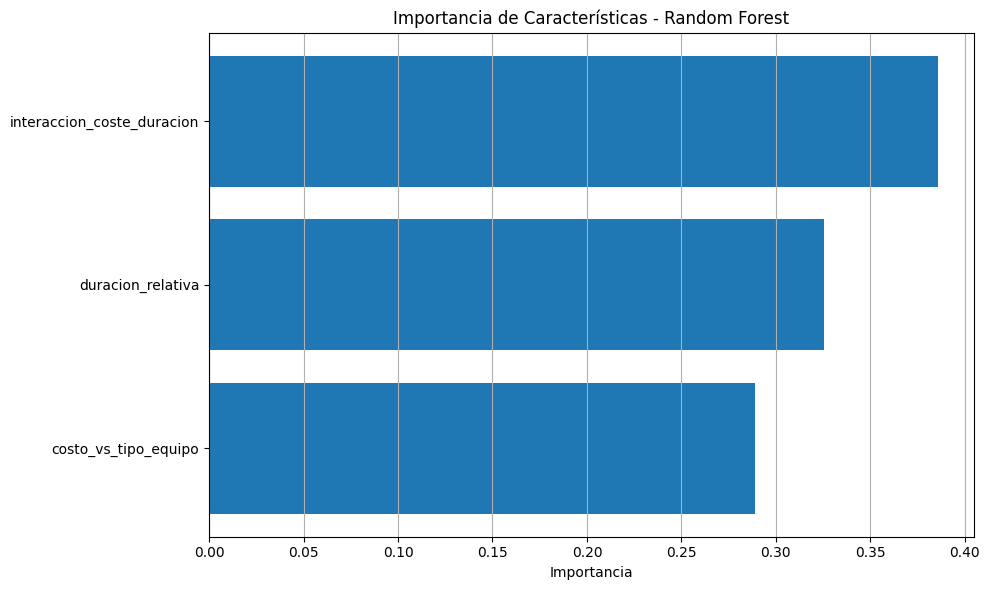

In [95]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

# Selección de variables
features = [   
'duracion_relativa',
'interaccion_coste_duracion',
'costo_vs_tipo_equipo'
]

X = ordenes_completo[features]
y = ordenes_completo['es_correctivo']

# División de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# Entrenamiento del modelo
clf = RandomForestClassifier(random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

# Importancia
importancias = pd.DataFrame({
    'feature': features,
    'importance': clf.feature_importances_
}).sort_values(by='importance', ascending=False)

# Mostrar tabla y gráfico
print("📊 Importancia de características:")
display(importancias)

# Gráfico
plt.figure(figsize=(10, 6))
plt.barh(importancias['feature'], importancias['importance'])
plt.xlabel("Importancia")
plt.title("Importancia de Características - Random Forest")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.grid(axis='x')
plt.show()


In [5]:
# Merge por ID_Equipo
anomalias_df = pd.merge(condiciones_df, caracteristicas_df, on="ID_Equipo", how="left")

# Mostrar las primeras filas del dataframe combinado
anomalias_df.head()

,ID_Registro,ID_Equipo,Fecha,Temperatura_C,Vibracion_mm_s,Horas_Operativas,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision
0,1,1,2021-01-01,36.587104,4.430381,579,Bomba,Fabricante_A,Modelo_8,432,657
1,2,106,2021-01-01,53.268051,0.534711,577,Motor,Fabricante_D,Modelo_3,448,801
2,3,446,2021-01-01,47.176472,7.116958,263,Generador,Fabricante_C,Modelo_2,95,561
3,4,107,2021-01-01,76.404597,2.696906,491,Compresor,Fabricante_A,Modelo_7,195,748
4,5,108,2021-01-01,50.729327,6.996772,589,Compresor,Fabricante_A,Modelo_9,181,560


In [6]:
# Crear la columna 'tiempo_fallo'
anomalias_df["tiempo_fallo"] = (
    anomalias_df["Horas_Recomendadas_Revision"] - anomalias_df["Horas_Operativas"]
)

# Mostrar las primeras filas para verificar
anomalias_df.head()


,ID_Registro,ID_Equipo,Fecha,Temperatura_C,Vibracion_mm_s,Horas_Operativas,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision,tiempo_fallo
0,1,1,2021-01-01,36.587104,4.430381,579,Bomba,Fabricante_A,Modelo_8,432,657,78
1,2,106,2021-01-01,53.268051,0.534711,577,Motor,Fabricante_D,Modelo_3,448,801,224
2,3,446,2021-01-01,47.176472,7.116958,263,Generador,Fabricante_C,Modelo_2,95,561,298
3,4,107,2021-01-01,76.404597,2.696906,491,Compresor,Fabricante_A,Modelo_7,195,748,257
4,5,108,2021-01-01,50.729327,6.996772,589,Compresor,Fabricante_A,Modelo_9,181,560,-29
